### Concepts shown in this demo notebook:

* Demonstrating how to train a PCTree on MNIST Data
* How PCA / SVD is just a special case of PCTree
* How to visualize a PCTree, including projection coefficients.
* How branch orthogonality makes encoding / decoding data with PCTrees simple.
* How each branch of a PCTree specializes in different data.
* How to save / load PCTrees into numpy files
* How to use PCTrees to efficiently encode data, and save this into numpy files.

`pip install pctree` Dependencies: `numpy`, `scipy`, `scikit-learn`

In [ ]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from pctree.training import PCTreeTrainerOptions, PCTreeTrainer
from pctree.display import get_pct_display_info, plot, plot_coeffs
from pctree.branches import EfficientEncodingRouter
from pctree.core import PCTreeCoefficients
from pctree.io import load_pctree, save_pctree

**Load Data and Learn a Principal Component Tree (Or load from `.npz` file)**. **Takes ~15 seconds on M2 Macbook Air.**

In [ ]:
mnist_X = np.load("../../data/mnist_train.npy").astype(np.float32)
X_mean = mnist_X.mean(axis=0); mnist_X -= X_mean

tree_pca = PCTreeTrainer.from_pca(mnist_X, n_components=11) #                  Try adjusting this sifting_effect_size! 
trainer = PCTreeTrainer(PCTreeTrainerOptions(50, max_children=5, max_width=10, sifting_effect_size=0.6))
trainer.fit_partition(mnist_X, verbose=1)
tree = trainer.fit_em(mnist_X, X_topdown=mnist_X, verbose=0)
# tree = load_pctree(npz_path="mnist_tree.npz") # save_pctree(tree, npz_path="mnist_tree.npz")

Performing top-down partitioning to create initial PCT. 
Log Key: `-` is a node expanded by adding one additional child. `<` is a node expanded by spliting into two nodes. 
<-<<<<<<<---<----<<<-<-<<<-<<---<-<-<------------


**Assign data to branches of the PCTree.** **Encode & decode data by projecting it onto a branch's subspace.**

In [12]:
branch_assignments = EfficientEncodingRouter(tree).predict(mnist_X)
data_i = 9; x = mnist_X[data_i]; x_branch = branch_assignments[data_i]; x_branch_inds = tree.branches()[x_branch]; rank = len(x_branch_inds)
V_br, V_pca = tree.V[x_branch_inds], tree_pca.V[:rank]
approx_br, approx_pca = (V_br @ x @ V_br) + X_mean, (V_pca @ x @ V_pca) + X_mean

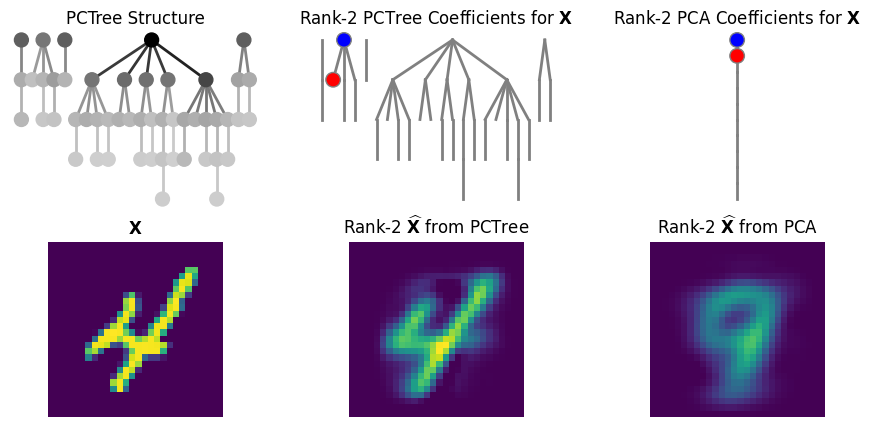

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(11, 5))
axes[0, 0].set_axis_off(); axes[0, 1].set_axis_off(); axes[0, 2].set_axis_off(); axes[1, 0].set_axis_off(); axes[1, 1].set_axis_off(); axes[1, 2].set_axis_off()
imshow_mnist = lambda digit, axes: axes.imshow(digit.reshape((28, 28)), vmin=0, vmax=255)
plot(get_pct_display_info(tree), axes[0, 0], size=100); axes[0, 0].set_title("PCTree Structure")
plot_coeffs(tree, get_pct_display_info(tree), x, x_branch_inds, axes[0, 1]); axes[0, 1].set_title(f"Rank-{rank} PCTree Coefficients for $\mathbf{{X}}$")
plot_coeffs(tree_pca, get_pct_display_info(tree_pca), x, np.arange(rank), axes[0, 2]); axes[0, 2].set_title(f"Rank-{rank} PCA Coefficients for $\mathbf{{X}}$")
imshow_mnist(x + X_mean, axes[1, 0]); imshow_mnist(approx_br, axes[1, 1]); imshow_mnist(approx_pca, axes[1, 2])
axes[1, 0].set_title("$\mathbf{X}$"); axes[1, 1].set_title(f"Rank-{rank} $\widehat{{\mathbf{{X}}}}$ from PCTree"); axes[1, 2].set_title(f"Rank-{rank} $\widehat{{\mathbf{{X}}}}$ from PCA");

**Encode and decode entire datasets more efficiently than PCA / SVD. Supports saving & loading to .npz files.**

In [14]:
C = PCTreeCoefficients(tree, mnist_X, branch_assignments)
mnist_X_approx = C.reconstruct(); 
average_pctree_encoding_size = C.average_scalars_used()
variance_captured = 1 - (((mnist_X - mnist_X_approx)**2).sum() / (mnist_X**2).sum())

_, s, _ = np.linalg.svd(mnist_X, full_matrices=False)
cumulative_pca_variance = (s**2).cumsum() / (s**2).sum()
equivilent_pca_encoding_size = np.interp(variance_captured, cumulative_pca_variance, np.arange(len(cumulative_pca_variance)))
print(f"Encoding data with a PCTree uses {round(average_pctree_encoding_size, 2)} scalars per data point.")
print(f"Encoding data with PCA / SVD would need {round(equivilent_pca_encoding_size, 2)} scalars per data point to reach the same quality.")

C.save("mnist_ecoded.npz"); # To load: PCTreeCoefficients.load_npz("mnist_ecoded.npz")

Encoding data with a PCTree uses 3.5 scalars per data point.
Encoding data with PCA / SVD would need 9.46 scalars per data point to reach the same quality.


**Checkout https://github.com/benkizaric/pctree for more demos and information! Or reach me at benkizaric@gmail.com.** 